In [55]:
from generador import generador
G, ni, xi, yi, dist=generador()

📂 Cargando grafo desde archivo local...
Agregando los nodos aleatorios
1 ,3 ,5 ,7 ,9 ,11 ,13 ,15 ,17 ,19 ,21 ,23 ,25 ,27 ,29 ,31 ,33 ,35 ,37 ,39 ,41 ,43 ,45 ,47 ,49 ,51 ,53 ,55 ,57 ,59 ,61 ,63 ,66 ,68 ,70 ,72 ,74 ,76 ,78 ,80 ,
82 ,84 ,86 ,88 ,90 ,92 ,94 ,96 ,98 ,100 ,102 ,104 ,106 ,108 ,110 ,112 ,114 ,116 ,118 ,120 ,
122 ,124 ,126 ,128 ,130 ,132 ,134 ,136 ,138 ,140 ,142 ,144 ,146 ,148 ,150 ,152 ,154 ,156 ,158 ,160 ,
162 ,164 ,166 ,168 ,170 ,172 ,174 ,176 ,178 ,180 ,182 ,184 ,186 ,188 ,190 ,192 ,194 ,196 ,198 ,200 ,
202 ,204 ,206 ,208 ,210 ,212 ,214 ,216 ,218 ,220 ,222 ,224 ,226 ,228 ,230 ,232 ,234 ,236 ,238 ,240 ,
242 ,244 ,246 ,248 ,250 ,252 ,254 ,256 ,258 ,260 ,262 ,264 ,266 ,268 ,270 ,272 ,274 ,276 ,278 ,280 ,
282 ,284 ,286 ,288 ,290 ,292 ,294 ,296 ,298 ,300 ,302 ,304 ,306 ,308 ,310 ,312 ,314 ,316 ,318 ,320 ,
322 ,324 ,326 ,328 ,330 ,332 ,334 ,336 ,338 ,340 ,342 ,344 ,346 ,348 ,350 ,352 ,354 ,356 ,358 ,360 ,
362 ,364 ,366 ,368 ,370 ,372 ,374 ,376 ,378 ,380 ,382 ,384 ,386 ,388 ,390 ,

100%|██████████| 401/401 [02:00<00:00,  3.33it/s]


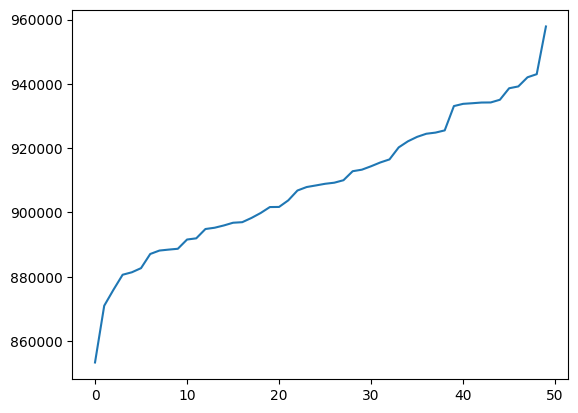

In [73]:
from networkx.algorithms.approximation import traveling_salesman_problem
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
origen=ni[-1] #Nodo de origen de todas las rutas. 
class solucion:
  def __init__(self, cromosoma=[], nbuses=20):
    self.n=len(ni)-1 #Número de niños, excluyendo el nodo origen
    self.nbuses=nbuses
    if(len(cromosoma)==0):
      self.X=np.random.randint(size=self.n, low=0, high=self.nbuses)
    else:
      self.X=cromosoma.copy()
      #print(self.X)
    self.Z=self.f() #Z es la variable que representa el valor de fitnness de la solución

  def f(self): #Función de Fitness
    #origen es el nodo origen, ahora los nodos tienen identificador como el número del nodo el OSM
    #Se debe solucionar la ruta óptima para cada bus, y luego sumar el costo total de las rutas.
    buses=[[origen] for i in range(self.nbuses)]
    for i in range(self.n):
      buses[self.X[i]].append(ni[i])
    #print(buses)
    #Creación del grafo para cada bus y solución del TSP para cada bus
    salida=0
    for bus in buses:
      Gbus=nx.DiGraph()
      for i in bus:
          for j in bus:
            if i!=j:
              #print(i,j)
              Gbus.add_edge(i, j, weight=dist[(i, j)])
      if(len(Gbus.nodes())==0):
        print('Bus sin nodos')
        print(bus)
      if(nx.is_strongly_connected(Gbus)):
        tour = traveling_salesman_problem(Gbus, cycle=True, weight='weight', method=nx.algorithms.approximation.greedy_tsp)
        costo=0
        #print('Tour:', tour)
        for i in range(len(tour)-1):
          n1=tour[i]
          n2=tour[i+1]
          costo += dist[(n1, n2)] 
      else:
        costo=1e6        
      salida+=costo

    return salida

  def graficar(self):
    pass

pob=[solucion() for i in range(50)]
Z=[ind.Z for ind in pob]
plt.plot(sorted(Z))


In [74]:
def prunning(P, Np): #Poda
  Z=np.array([xi.Z for xi in P])
  ind=np.argsort(-Z)
  ind=[ind[int(i)] for i in range(Np)]
  P=[P[i] for i in range(len(P)) if i not in ind]
  return P

def mutacion(P, Nm, num): #num representa cuantos genes modificamos
  #Vamos a elegir para mutar, a las soluciones más malas. Conservando las mejores con menor probabilidad de mutación
  for i in np.random.choice(size=Nm, a=range(len(P))):
    #Voy a modificar la función de mutación, aumentando la probabilidad a los valores de vi más cercanos a la diferencia con la cantidad deseada
    for j in np.random.choice(size=num, a=range(len(P[i].X))):
        P[i].X[j]=np.random.randint(low=0, high=P[i].nbuses)
    P[i].Z=P[i].f()
  return P

def reproduccion(P, Nc):
  ind=np.random.randint(size=(Nc,2), low=0, high=len(P))
  L=int(len(P[0].X)/2)
  for i,j in ind:
    Xi=P[i].X.copy()
    Xj=P[j].X.copy()
    cromosoma=np.concatenate([Xi[:L],Xj[L:]])
    if(len(cromosoma)!=len(P[0].X)):
      print('Error en la longitud del cromosoma', Xi, Xj, cromosoma)
    P.append(solucion(cromosoma=np.concatenate([Xi[:L],Xj[L:]]), nbuses=P[i].nbuses))
  return P

Mejor Z original:  853329.9877335987
Mejor Z Luego de prunning:  853329.9877335987
Mejor Z luego de mutación:  853329.9877335987
Mejor Z luego de reproducción:  853329.9877335987


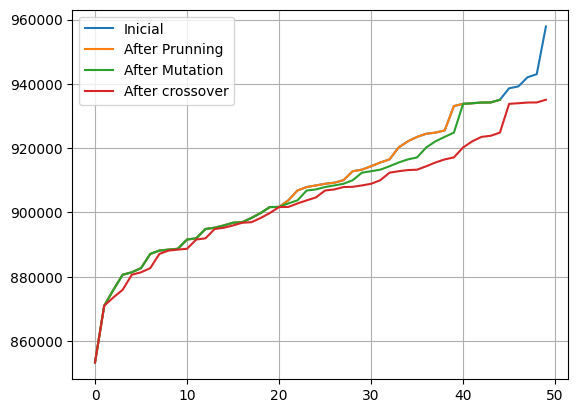

In [75]:
P=pob
Np=5 #Dimensión del prunning
Nm=5 #Dimensión de la mutación
Nc=5
Z=[xi.Z for xi in P]
print('Mejor Z original: ', min(Z))
plt.plot(sorted(Z), label='Inicial')
P=prunning(P, Np)
Z=[xi.Z for xi in P]
print('Mejor Z Luego de prunning: ', min(Z))
plt.plot(sorted(Z), label='After Prunning')
P=mutacion(P, Nm, 1000)
Z=[xi.Z for xi in P]
print('Mejor Z luego de mutación: ', min(Z))
plt.plot(sorted(Z), label='After Mutation')
P=reproduccion(P, Nc)
Z=[xi.Z for xi in P]
print('Mejor Z luego de reproducción: ', min(Z))
plt.plot(sorted(Z), label='After crossover')
plt.legend()

plt.grid()

Mejor valor de Z: 863177.4305607884
Mejor solucion inicial:  863177.4305607884
Iteración:  133 , Mejor valor:  822403.6184181015Bus sin nodos
[1559490216, 1559490216, 1559490216, 1559490216, 1559490216, 1559490216, 1559490216, 1559490216, 1559490216, 1559490216]


NetworkXPointlessConcept: Connectivity is undefined for the null graph.

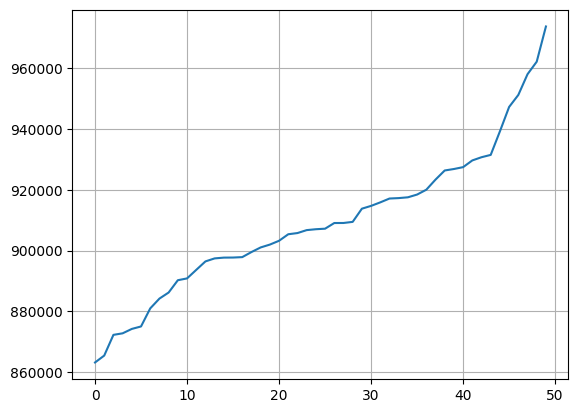

In [76]:
#Definiciones del algoritmo genético
m=50 #Tamaño de la población
Np=int(m/10) #Dimensión del prunning
Nm=int(m/10) #Dimensión de la mutación
Nc=int(m/10) #Dimensión de la reproducción

P=[solucion() for i in range(m)]
Z=[xi.Z for xi in P] #Valor de fitness de todas las soluciones
plt.plot(sorted(Z))
plt.grid()
print('Mejor valor de Z:',min(Z))

from tqdm import tqdm
NumIter=5000
print('Mejor solucion inicial: ',min(Z))
best=solucion(P[np.argmin(Z)].X)
error=[best.Z]
mejor=solucion(P[np.argmin(Z)].X)
#print('Mejor solución al incio: ', best.Z)
dv=10
for i in range(NumIter):
  P=prunning(P, Np)
  P=mutacion(P, Nm,10)
  P=reproduccion(P, Nc)
  Z=[xi.Z for xi in P]
  if(i%dv==0):
    print('\rIteración: ',i,', Mejor valor: ',best.Z, end='')
  mejor=solucion(P[np.argmin(Z)].X)
  if(mejor.Z<best.Z):
    best=solucion(mejor.X)
    print('\rIteración: ',i,', Mejor valor: ',best.Z, end='')
  error.append(best.Z)

  if(best.Z==0):
    print('Solución encontrada')
    break
#plt.plot(sorted(Z), label='Final')
#plt.legend()
#plt.xlabel('Población')
#plt.ylabel('Fitness')
#plt.grid()
plt.figure()
plt.plot(error)
plt.xlabel('Iteraciones')
plt.ylabel('Fitness')
plt.grid()

In [63]:
P


In [65]:
np.unique([len(pi.X) for pi in P])

array([400])